# Single run model-free hypervolume

Scalarized UCB and Scalarized Knowledge Gradient (KG), with separate **RTS** and **STR** formulations. The six experiment pairs cover gravity heterogeneity, synchronization, and request-rate heterogeneity under holistic and Cheetah reductionist formulations. All current results use simulated OU rewards and one independent run.

Both algorithms use **7 arms, 7 positive unit directions, and 150 online requests**, the largest online budget used in the pilot. UCB initializes each arm-direction pair once (**49** requests), leaving **101** adaptive choices. KG initializes every pair twice (**98** requests), leaving **52** adaptive choices. The two dotted vertical lines mark these initialization boundaries.

Both now minimize the same normalized cost length scalarization from the paper's Eq. 26, using the fixed lower reference **[-0.01, -0.01]**. Incremental overhead is divided by 40 times the largest class payload (holistic) or the Cheetah payload (reductionist); instability is divided by 1. UCB's earlier transformed-reward convention has been replaced for this comparison. Earlier files are archived.

Holistic arms evenly span [0,1] and map to the active class's fitness-margin interval. Reductionist arms evenly span the physical Cheetah margin interval [-10,20]. The online budget is distinct from the held-out sequence horizon:

| Approach | Online requests | Held-out sequence length | Overhead reference (KiB) | Instability reference |
|---|---:|---:|---:|---:|
| Holistic | 150 | 100 | 2,200,000 | 310 |
| Cheetah reductionist | 150 | 50 | 90,497.578125 | 85 |

The upper total-cost hypervolume references and held-out horizons match the corresponding MORBO/qNParEGO experiments. At each online checkpoint, the empirical exploitation maximizers across directions form a recommended arm subset. Its possible sequences are approximated by 16 common Sobol sequences plus all constant sequences, removing duplicates. Each sequence has two held-out realizations. Hypervolume uses the shared RTS/STR polar calculation with 128 angular midpoint directions. Evaluation data never update either bandit.

Seeds, held-out scenarios, and Sobol designs are paired across algorithms and conditions. Curves show the currently recommended subset, without smoothing or cumulative maxima; decreases are possible. These are single-run results without confidence intervals. They describe performance under these settings, rather than establish that either algorithm succeeds or fails generally. Model-based search and evaluation budgets still differ.

This notebook preserves the original single-run figures. The completed ten-run means and shaded variability bands are in [Multiple run model-free hypervolume](<Multiple run model-free hypervolume.ipynb>).


In [1]:
from pathlib import Path
import hashlib
import json
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Markdown, display

root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "Scalarized UCB" / "setup_holistic_gravity.json").is_file()), None)
if root is None:
    raise FileNotFoundError("Open this notebook from the Cosmic Octopi project.")
folders = {"UCB": "Scalarized UCB", "KG": "Scalarized Knowledge Gradient"}


def load_bandit_result(algorithm, approach, experiment):
    folder = root / folders[algorithm]
    setup = json.loads((folder / f"setup_{approach}_{experiment}.json").read_text(encoding="utf-8"))
    with (folder / setup["output_file"]).open("rb") as file:
        result = pickle.load(file)
    if not result["complete"] or result["setup"] != setup:
        raise ValueError(f"Complete/update {folders[algorithm]}/script_{approach}_{experiment}.py first.")
    for name, digest in result["source_sha256"].items():
        if hashlib.sha256((root / name).read_bytes()).hexdigest() != digest:
            raise ValueError(f"Results predate a source change: {name}")
    xi = json.loads((folder / setup["xi_matrix_file"]).read_text(encoding="utf-8"))
    if any(not np.array_equal(result["xi_matrices"][name], values) for name, values in xi.items()):
        raise ValueError("Calibration changed; update the results before plotting.")
    if len(result["arms"]) != 7 or len(result["scalarization_directions"]) != 7:
        raise ValueError("Expected the current 7-arm, 7-direction results")
    return result


def load_pair(approach, experiment):
    pair = {a: load_bandit_result(a, approach, experiment) for a in folders}
    one, two = pair["UCB"]["setup"], pair["KG"]["setup"]
    for key in (approach, "reference_costs", "sweep", "system_dynamics_parameters", "evaluation"):
        if one[key] != two[key]:
            raise ValueError(f"UCB/KG comparison settings differ: {key}")
    for key in ("n_arms", "n_scalarization_directions", "n_online_iterations", "cost_reference", "observation_normalization"):
        if one["bandit"][key] != two["bandit"][key]:
            raise ValueError(f"UCB/KG bandit settings differ: {key}")
    return pair


def plot_comparison(pair, formulation):
    setup = pair["UCB"]["setup"]
    sweep = setup["sweep"]
    all_values = np.concatenate([np.asarray(run["hypervolume_history"]) for record in pair.values() for run in record["runs"].values()])
    padding = max(0.005, 0.08 * np.ptp(all_values))
    fig, ax = plt.subplots(figsize=(6, 5))
    for color, level in zip(["#1f77b4", "#ff7f0e"], sweep["values"]):
        for algorithm, linestyle, marker in [("UCB", "-", "o"), ("KG", "--", "s")]:
            run = pair[algorithm]["runs"][f"{formulation}/{sweep['parameter']}={level:g}"]
            if not run["complete"] or run["checkpoint_iterations"] != list(range(1,151)):
                raise ValueError("Expected all 150 checkpoints")
            label = "Sc-" + algorithm + r", $\gamma_{\mathrm{" + sweep["symbol"] + "}} = " + f"{level:g}" + "$"
            ax.plot(run["checkpoint_iterations"], run["hypervolume_history"], color=color,
                    linestyle=linestyle, marker=marker, markersize=3.5, markevery=10,
                    linewidth=2, label=label)
    for algorithm in ("UCB", "KG"):
        b = pair[algorithm]["setup"]["bandit"]
        initialization = b["n_arms"] * b["n_scalarization_directions"] * b.get("initial_pulls_per_pair", 1)
        ax.axvline(initialization, color="0.65", linestyle=":", linewidth=0.8)
    ax.set_xlabel("Global iteration" if setup["approach"] == "holistic" else "Cheetah request", fontsize=14)
    ax.set_ylabel("Normalized hypervolume", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.set_xlim(1,150)
    ax.set_ylim(max(0, all_values.min()-padding), all_values.max()+padding)
    ax.grid(False)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

bandit_results = {}


## Holistic / Gravity heterogeneity

$\gamma_{\mathrm{grav}}=1$ versus $5$, with synchronization 1 and request heterogeneity 0.5.

In [2]:
bandit_results["holistic_gravity"] = load_pair("holistic", "gravity")

### RTS: robustify, then scalarize

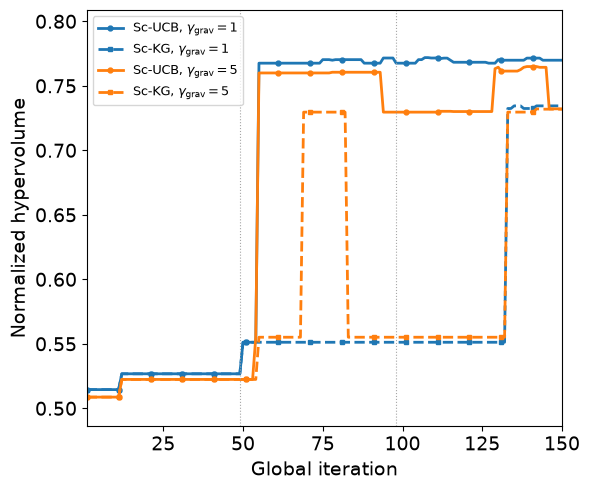

In [3]:
plot_comparison(bandit_results["holistic_gravity"], "RTS")

### STR: scalarize, then robustify

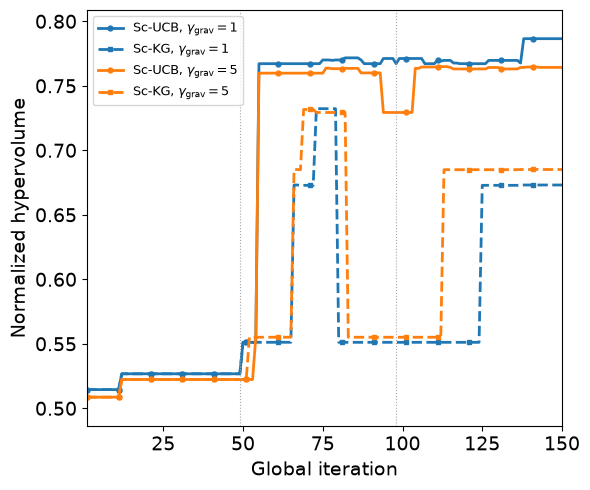

In [4]:
plot_comparison(bandit_results["holistic_gravity"], "STR")

## Reductionist: Cheetah / Gravity heterogeneity

$\gamma_{\mathrm{grav}}=1$ versus $5$, with synchronization 1 and request heterogeneity 0.5.

In [5]:
bandit_results["reductionist_gravity"] = load_pair("reductionist", "gravity")

### RTS: robustify, then scalarize

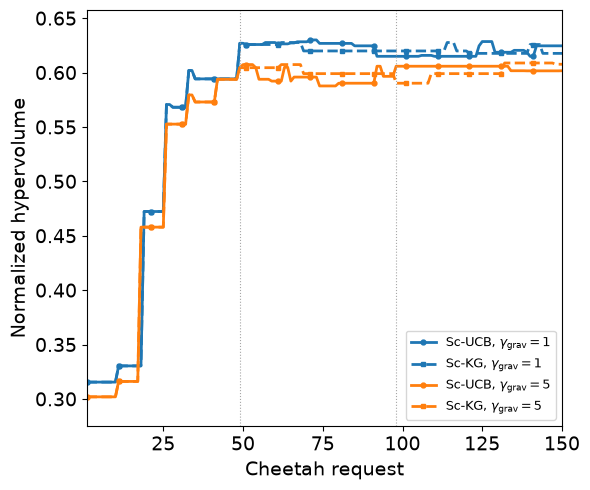

In [6]:
plot_comparison(bandit_results["reductionist_gravity"], "RTS")

### STR: scalarize, then robustify

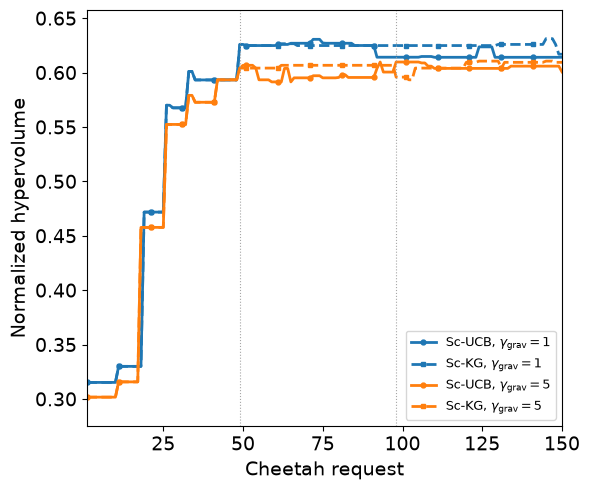

In [7]:
plot_comparison(bandit_results["reductionist_gravity"], "STR")

## Holistic / Synchronization

$\gamma_{\mathrm{sync}}=1$ versus $0.8$, with gravity variance 0.1 and request heterogeneity 0.5.

In [8]:
bandit_results["holistic_synchronization"] = load_pair("holistic", "synchronization")

### RTS: robustify, then scalarize

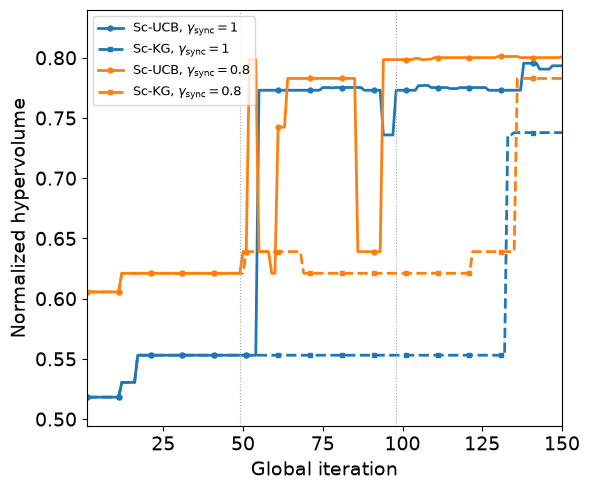

In [9]:
plot_comparison(bandit_results["holistic_synchronization"], "RTS")

### STR: scalarize, then robustify

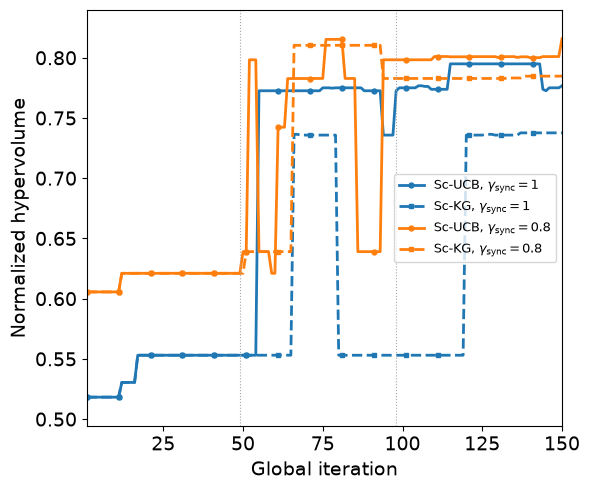

In [10]:
plot_comparison(bandit_results["holistic_synchronization"], "STR")

## Reductionist: Cheetah / Synchronization

$\gamma_{\mathrm{sync}}=1$ versus $0.8$, with gravity variance 0.1 and request heterogeneity 0.5.

In [11]:
bandit_results["reductionist_synchronization"] = load_pair("reductionist", "synchronization")

### RTS: robustify, then scalarize

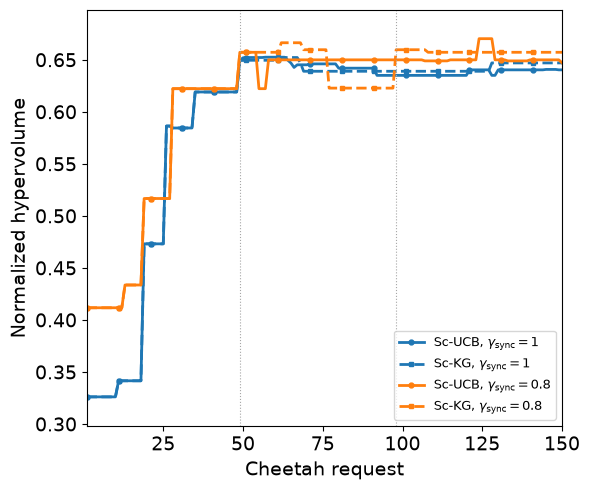

In [12]:
plot_comparison(bandit_results["reductionist_synchronization"], "RTS")

### STR: scalarize, then robustify

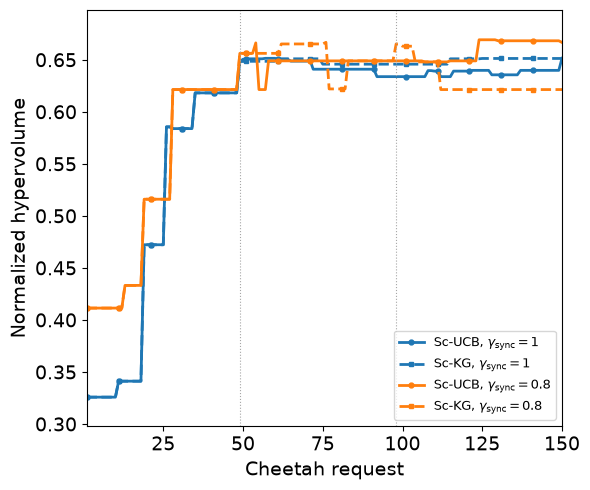

In [13]:
plot_comparison(bandit_results["reductionist_synchronization"], "STR")

## Holistic / Request-rate heterogeneity

$\gamma_{\mathrm{heter}}=0.1$ versus $0.8$, with gravity variance 0.1 and synchronization 1.

In [14]:
bandit_results["holistic_heterogeneity"] = load_pair("holistic", "heterogeneity")

### RTS: robustify, then scalarize

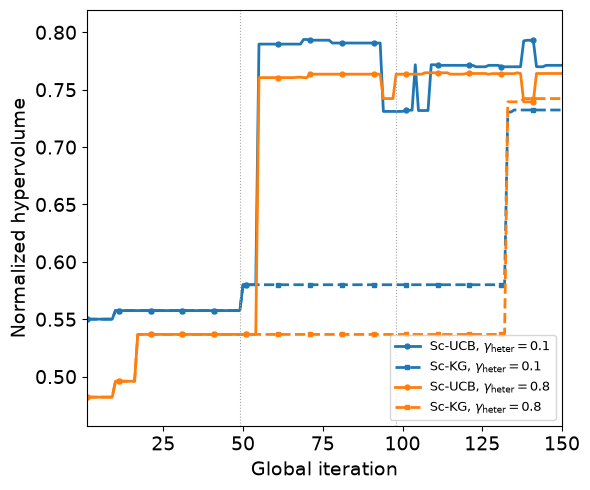

In [15]:
plot_comparison(bandit_results["holistic_heterogeneity"], "RTS")

### STR: scalarize, then robustify

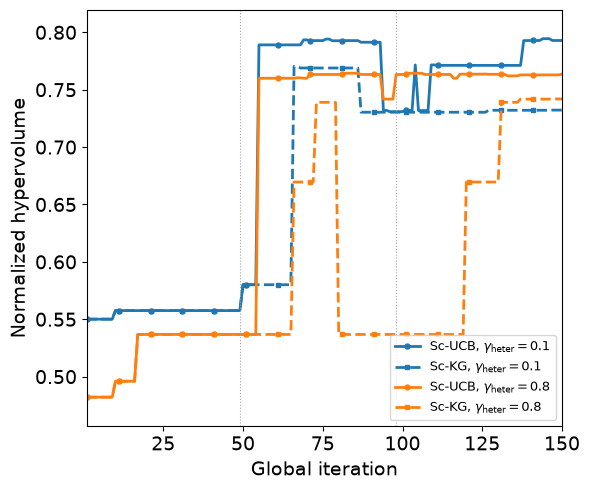

In [16]:
plot_comparison(bandit_results["holistic_heterogeneity"], "STR")

## Reductionist: Cheetah / Request-rate heterogeneity

$\gamma_{\mathrm{heter}}=0.1$ versus $0.8$, with gravity variance 0.1 and synchronization 1.

In [17]:
bandit_results["reductionist_heterogeneity"] = load_pair("reductionist", "heterogeneity")

### RTS: robustify, then scalarize

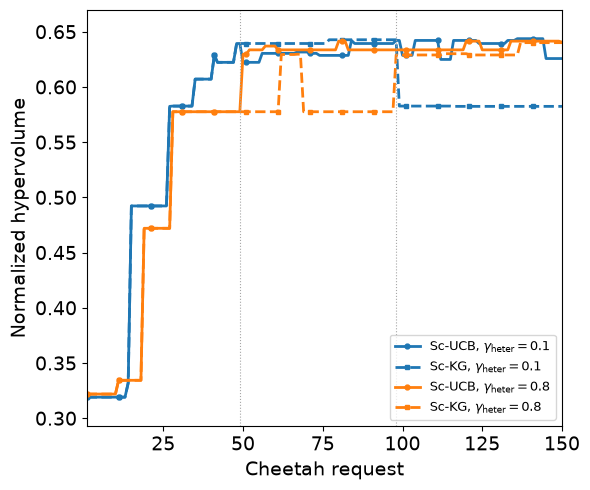

In [18]:
plot_comparison(bandit_results["reductionist_heterogeneity"], "RTS")

### STR: scalarize, then robustify

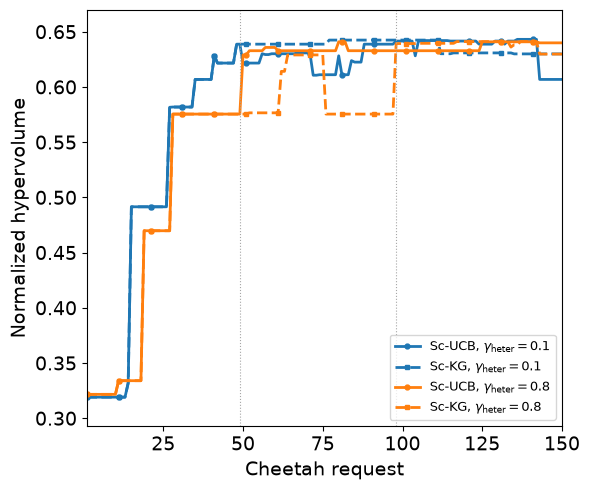

In [19]:
plot_comparison(bandit_results["reductionist_heterogeneity"], "STR")

## Final estimates

Recommended arms are normalized values for holistic runs and physical Cheetah margins for reductionist runs.

In [20]:
rows = ["| Experiment | Approach | Algorithm | Formulation | Sweep value | Final hypervolume | Recommended arms |",
        "|---|---|---|---|---:|---:|---|"]
for pair in bandit_results.values():
    for algorithm, result in pair.items():
        for run in result["runs"].values():
            selected = ", ".join(f"{value:.3f}" for value in result["arms"][run["recommended_arms"][-1]])
            rows.append(f"| {result['experiment']} | {result['approach']} | {algorithm} | {run['formulation']} | "
                        f"{run['sweep_value']:g} | {run['hypervolume_history'][-1]:.6f} | {selected} |")
display(Markdown("\n".join(rows)))


| Experiment | Approach | Algorithm | Formulation | Sweep value | Final hypervolume | Recommended arms |
|---|---|---|---|---:|---:|---|
| gravity | holistic | UCB | RTS | 1 | 0.769815 | 0.000, 0.167, 0.500, 0.833 |
| gravity | holistic | UCB | STR | 1 | 0.786513 | 0.000, 0.167, 0.833, 1.000 |
| gravity | holistic | UCB | RTS | 5 | 0.732043 | 0.000, 0.167, 0.333, 0.500, 0.667 |
| gravity | holistic | UCB | STR | 5 | 0.764242 | 0.000, 0.500, 0.667, 0.833 |
| gravity | holistic | KG | RTS | 1 | 0.734429 | 0.000, 0.167, 0.333, 0.500, 0.667 |
| gravity | holistic | KG | STR | 1 | 0.673086 | 0.000, 0.333, 0.500 |
| gravity | holistic | KG | RTS | 5 | 0.731862 | 0.000, 0.167, 0.500, 0.667 |
| gravity | holistic | KG | STR | 5 | 0.685087 | 0.000, 0.333, 0.500 |
| gravity | reductionist | UCB | RTS | 1 | 0.624548 | -10.000, 15.000, 20.000 |
| gravity | reductionist | UCB | STR | 1 | 0.614010 | -10.000, 10.000, 15.000 |
| gravity | reductionist | UCB | RTS | 5 | 0.601651 | -10.000, -5.000, 0.000, 15.000, 20.000 |
| gravity | reductionist | UCB | STR | 5 | 0.600586 | -10.000, -5.000, 15.000, 20.000 |
| gravity | reductionist | KG | RTS | 1 | 0.617607 | -10.000, -5.000, 0.000, 20.000 |
| gravity | reductionist | KG | STR | 1 | 0.616834 | -10.000, -5.000, 0.000, 20.000 |
| gravity | reductionist | KG | RTS | 5 | 0.607622 | -10.000, -5.000, 0.000, 5.000, 20.000 |
| gravity | reductionist | KG | STR | 5 | 0.609373 | -10.000, -5.000, 0.000, 5.000, 10.000, 20.000 |
| synchronization | holistic | UCB | RTS | 1 | 0.793326 | 0.000, 0.167, 0.333, 0.500, 1.000 |
| synchronization | holistic | UCB | STR | 1 | 0.776735 | 0.000, 0.333, 0.500, 0.667, 0.833 |
| synchronization | holistic | UCB | RTS | 0.8 | 0.800838 | 0.000, 0.167, 0.500, 0.833 |
| synchronization | holistic | UCB | STR | 0.8 | 0.815840 | 0.000, 0.500, 0.667, 0.833, 1.000 |
| synchronization | holistic | KG | RTS | 1 | 0.737848 | 0.000, 0.167, 0.333, 0.500, 0.667 |
| synchronization | holistic | KG | STR | 1 | 0.737641 | 0.000, 0.167, 0.333, 0.500, 0.667 |
| synchronization | holistic | KG | RTS | 0.8 | 0.782849 | 0.000, 0.167, 0.333, 0.667 |
| synchronization | holistic | KG | STR | 0.8 | 0.784715 | 0.167, 0.333, 0.500, 0.667 |
| synchronization | reductionist | UCB | RTS | 1 | 0.640263 | -10.000, -5.000, 0.000, 5.000, 10.000, 15.000 |
| synchronization | reductionist | UCB | STR | 1 | 0.651413 | -10.000, 0.000, 5.000, 10.000, 15.000, 20.000 |
| synchronization | reductionist | UCB | RTS | 0.8 | 0.647006 | -10.000, 5.000, 10.000 |
| synchronization | reductionist | UCB | STR | 0.8 | 0.666593 | -10.000, -5.000, 5.000, 10.000, 20.000 |
| synchronization | reductionist | KG | RTS | 1 | 0.646921 | -10.000, -5.000, 0.000, 10.000, 20.000 |
| synchronization | reductionist | KG | STR | 1 | 0.651207 | -5.000, 0.000, 5.000, 10.000, 20.000 |
| synchronization | reductionist | KG | RTS | 0.8 | 0.657138 | -10.000, -5.000, 0.000, 20.000 |
| synchronization | reductionist | KG | STR | 0.8 | 0.621318 | -10.000, -5.000, 0.000, 5.000 |
| heterogeneity | holistic | UCB | RTS | 0.1 | 0.771232 | 0.000, 0.667, 0.833 |
| heterogeneity | holistic | UCB | STR | 0.1 | 0.792880 | 0.000, 0.667, 0.833, 1.000 |
| heterogeneity | holistic | UCB | RTS | 0.8 | 0.764129 | 0.000, 0.333, 0.667, 0.833 |
| heterogeneity | holistic | UCB | STR | 0.8 | 0.763619 | 0.000, 0.167, 0.500, 0.667, 0.833 |
| heterogeneity | holistic | KG | RTS | 0.1 | 0.732319 | 0.000, 0.167, 0.333, 0.500, 0.667 |
| heterogeneity | holistic | KG | STR | 0.1 | 0.732222 | 0.167, 0.333, 0.500, 0.667 |
| heterogeneity | holistic | KG | RTS | 0.8 | 0.742263 | 0.000, 0.167, 0.333, 0.500, 0.667 |
| heterogeneity | holistic | KG | STR | 0.8 | 0.741962 | 0.167, 0.333, 0.500, 0.667 |
| heterogeneity | reductionist | UCB | RTS | 0.1 | 0.625676 | 0.000, 5.000, 10.000, 20.000 |
| heterogeneity | reductionist | UCB | STR | 0.1 | 0.606763 | -10.000, 0.000, 5.000, 10.000 |
| heterogeneity | reductionist | UCB | RTS | 0.8 | 0.640465 | -10.000, -5.000, 5.000, 15.000, 20.000 |
| heterogeneity | reductionist | UCB | STR | 0.8 | 0.639879 | -10.000, -5.000, 5.000, 15.000, 20.000 |
| heterogeneity | reductionist | KG | RTS | 0.1 | 0.582365 | -10.000, -5.000, 0.000, 5.000 |
| heterogeneity | reductionist | KG | STR | 0.1 | 0.629879 | -10.000, -5.000, 5.000, 15.000 |
| heterogeneity | reductionist | KG | RTS | 0.8 | 0.640058 | -10.000, -5.000, 0.000, 5.000, 20.000 |
| heterogeneity | reductionist | KG | STR | 0.8 | 0.629715 | -5.000, 0.000, 5.000, 10.000, 15.000 |

## KG exploration diagnostics

Counts cover the 52 adaptive requests. Choices are compared with the empirical exploitation maximizer before observing the request. Exact score ties select the smallest arm index. In RTS, the paper's positive-part operation can create ties when exploration bonuses move optimistic costs below the reference.

In [21]:
rows = ["| Experiment | Approach | Formulation | Sweep value | Choices differing from greedy | Tied winning score |",
        "|---|---|---|---:|---:|---:|"]
for pair in bandit_results.values():
    result = pair["KG"]
    for run in result["runs"].values():
        decisions = run["adaptive_decisions"]
        changed = sum(run["arm_history"][d["iteration"]-1] != np.argmax(d["exploitation_scores"]) for d in decisions)
        ties = sum(np.count_nonzero(d["scores"] == np.max(d["scores"])) > 1 for d in decisions)
        rows.append(f"| {result['experiment']} | {result['approach']} | {run['formulation']} | "
                    f"{run['sweep_value']:g} | {changed}/{len(decisions)} | {ties}/{len(decisions)} |")
display(Markdown("\n".join(rows)))


| Experiment | Approach | Formulation | Sweep value | Choices differing from greedy | Tied winning score |
|---|---|---|---:|---:|---:|
| gravity | holistic | RTS | 1 | 37/52 | 15/52 |
| gravity | holistic | STR | 1 | 36/52 | 0/52 |
| gravity | holistic | RTS | 5 | 39/52 | 21/52 |
| gravity | holistic | STR | 5 | 37/52 | 0/52 |
| gravity | reductionist | RTS | 1 | 24/52 | 1/52 |
| gravity | reductionist | STR | 1 | 32/52 | 0/52 |
| gravity | reductionist | RTS | 5 | 24/52 | 1/52 |
| gravity | reductionist | STR | 5 | 37/52 | 0/52 |
| synchronization | holistic | RTS | 1 | 42/52 | 12/52 |
| synchronization | holistic | STR | 1 | 39/52 | 0/52 |
| synchronization | holistic | RTS | 0.8 | 35/52 | 13/52 |
| synchronization | holistic | STR | 0.8 | 31/52 | 0/52 |
| synchronization | reductionist | RTS | 1 | 23/52 | 0/52 |
| synchronization | reductionist | STR | 1 | 30/52 | 0/52 |
| synchronization | reductionist | RTS | 0.8 | 24/52 | 0/52 |
| synchronization | reductionist | STR | 0.8 | 28/52 | 0/52 |
| heterogeneity | holistic | RTS | 0.1 | 40/52 | 18/52 |
| heterogeneity | holistic | STR | 0.1 | 38/52 | 0/52 |
| heterogeneity | holistic | RTS | 0.8 | 40/52 | 13/52 |
| heterogeneity | holistic | STR | 0.8 | 38/52 | 0/52 |
| heterogeneity | reductionist | RTS | 0.1 | 22/52 | 2/52 |
| heterogeneity | reductionist | STR | 0.1 | 34/52 | 0/52 |
| heterogeneity | reductionist | RTS | 0.8 | 26/52 | 1/52 |
| heterogeneity | reductionist | STR | 0.8 | 32/52 | 0/52 |